# FIDE Players Database

Data from [the FIDE website](https://ratings.fide.com/download_lists.phtml).

## TODO

- [X] Player Rating Distribution
- [ ] Player Age Distribution
- [ ] Player Country Distribution (Bar Chart probably)

In [ ]:
import pandas as pd

In [ ]:
fide_file = '../datasets/chess_fide_players.csv'
fide = pd.read_fwf(fide_file)

display(fide.head())

,ID_Number,Name,Fed,Sex,Tit,WTit,OTit,FOA,SRtng,SGm,SK,RRtng,RGm,Rk,BRtng,BGm,BK,B-day,Flag
0,40132986,"-Moonen, Bas",NED,M,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,2001,NaN
1,554022347,554022339,KEN,M,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,1975,NaN
2,564033791,564033783,IND,M,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,2017,NaN
3,40131955,9116162,NED,F,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,1994,w
4,40129322,9147028,NED,M,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1530,0,20,1995,NaN


In [7]:
display(fide.describe())

,ID_Number,SRtng,SGm,SK,RRtng,RGm,Rk,BRtng,BGm,BK,B-day
count,1.857688e+06,1.857688e+06,1.857688e+06,1.857688e+06,1.857688e+06,1.857688e+06,1.857688e+06,1.857688e+06,1.857688e+06,1.857688e+06,1.857688e+06
mean,1.170064e+08,5.155256e+02,1.703752e-01,9.317593e+00,4.057534e+02,1.393377e-01,7.213304e+00,2.782046e+02,1.081742e-01,4.102925e+00,1.960240e+03
std,2.006098e+08,8.048123e+02,1.173161e+00,1.538803e+01,7.265890e+02,1.189868e+00,1.372152e+01,6.406165e+02,1.306563e+00,1.004779e+01,2.673407e+02
min,1.000130e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.708388e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.985000e+03
50%,2.424028e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.003000e+03
75%,5.459830e+07,1.505000e+03,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.010000e+03
max,7.060883e+08,2.840000e+03,3.800000e+01,4.000000e+01,2.832000e+03,2.050000e+02,4.000000e+01,2.869000e+03,2.700000e+02,4.000000e+01,2.024000e+03


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

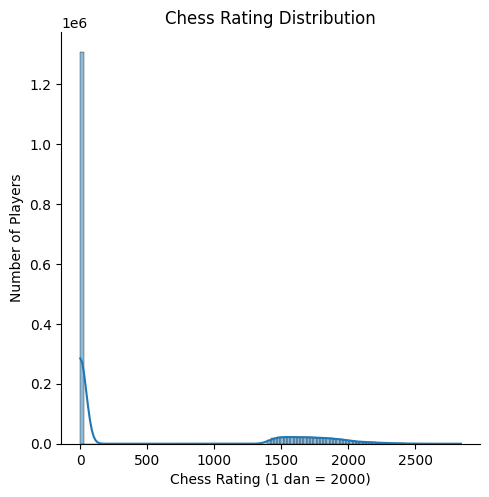

In [13]:
sns.displot(data=fide, x="SRtng", kde=True)
plt.xlabel('Chess Rating (1 dan = 2000)')
plt.ylabel('Number of Players')
plt.title('Chess Rating Distribution')
plt.show()

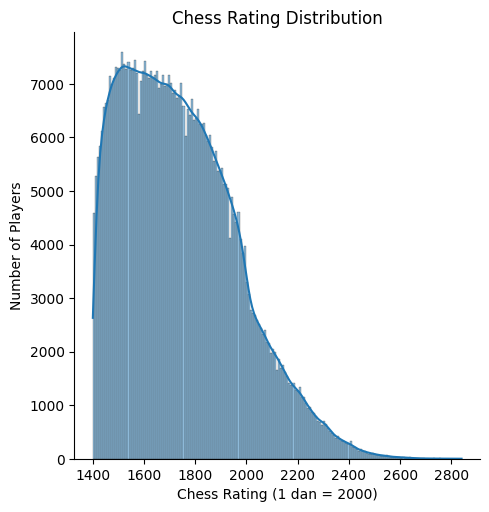

In [ ]:
sns.displot(data=fide[fide["SRtng"] > 0], x="SRtng", kde=True)
plt.xlabel('Chess Rating')
plt.ylabel('Number of Players')
plt.title('Chess Rating Distribution')
plt.show()

TODO: Make the graph above prettier (maybe use another package...)

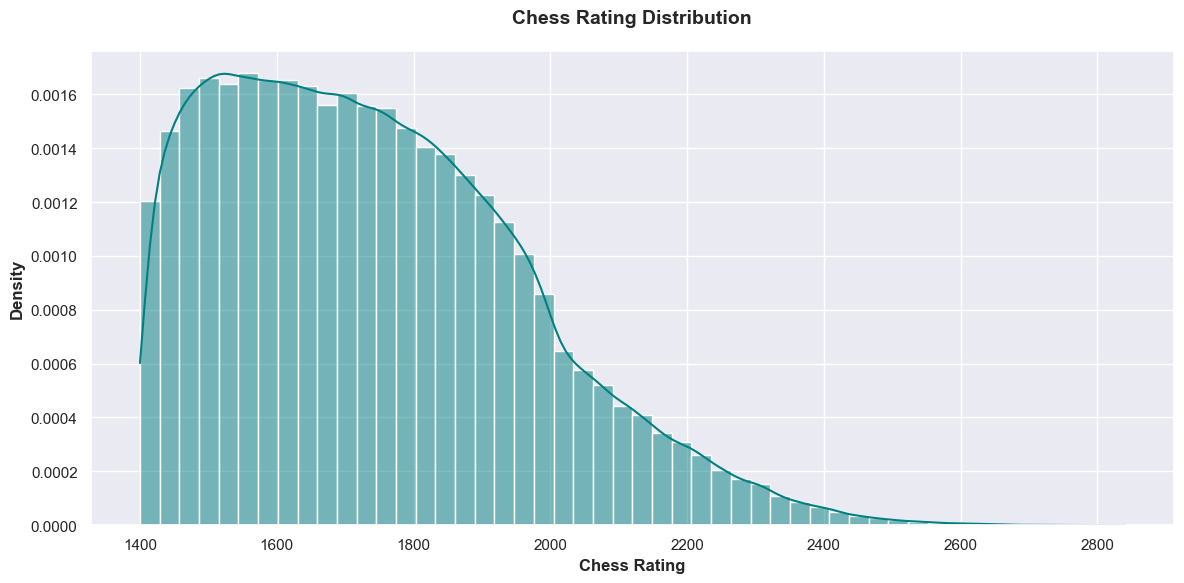

In [14]:
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data=fide[fide["SRtng"] > 0], x="SRtng", kde=True, color="teal", stat="density", ax=ax, bins=50)
ax.set_xlabel('Chess Rating', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Chess Rating Distribution', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

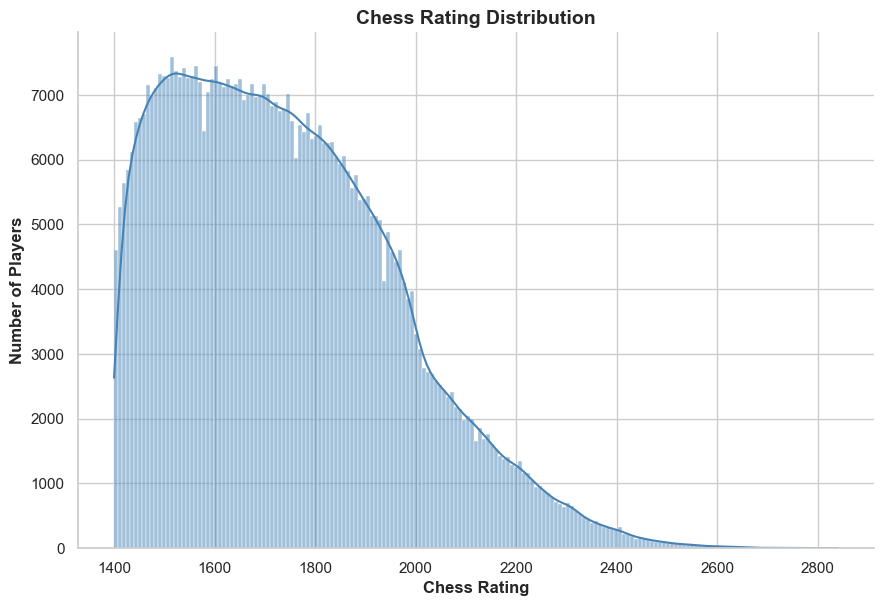

In [ ]:
sns.set_style("whitegrid")
sns.displot(data=fide[fide["SRtng"] > 0], x="SRtng", kde=True, color="steelblue", height=6, aspect=1.5)
plt.xlabel('Chess Rating', fontsize=12, fontweight='bold')
plt.ylabel('Number of Players', fontsize=12, fontweight='bold')
plt.title('Chess Rating Distribution', fontsize=14, fontweight='bold')
plt.show()

In [22]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.transform import dodge
import numpy as np

output_notebook()
hist, edges = np.histogram(fide[fide["SRtng"] > 0]["SRtng"], bins=50)

p = figure(title="Chess Rating Distribution", background_fill_color="#fafafa", width=800, height=400)
p.quad(top=hist, bottom=0, left=edges[:-1], right=edges[1:], fill_color="navy", line_color="white", alpha=0.8)
p.xaxis.axis_label = "Chess Rating"
p.yaxis.axis_label = "Number of Players"
show(p)

Loading BokehJS ...

In [34]:
import plotly.express as px

fig = px.histogram(
    fide[fide["SRtng"] > 0],
    x="SRtng",
    nbins=50,
    title="Chess Rating Distribution",
    labels={"SRtng": "Chess Rating"},
    opacity=0.8
)
fig.update_layout(yaxis_title="Number of Players")
fig.show()

In [ ]:
import altair as alt

# Altair only works with smaller datasets.
data = fide[fide["SRtng"] > 0].sample(n=5000, random_state=42)

chart = alt.Chart(data).transform_density(
    "SRtng",
    as_=["SRtng", "density"],
    bandwidth=50
).mark_area(opacity=0.6, color="teal").encode(
    x=alt.X("SRtng:Q", title="Chess Rating"),
    y=alt.Y("density:Q", title="Density"),
    tooltip=[
        alt.Tooltip("SRtng:Q", title="Rating"),
        alt.Tooltip("density:Q", title="Density", format=".4f")
    ]
).properties(
    title="Chess Rating Density Estimate",
    width=700,
    height=400
)

chart.show()

alt.Chart(...)

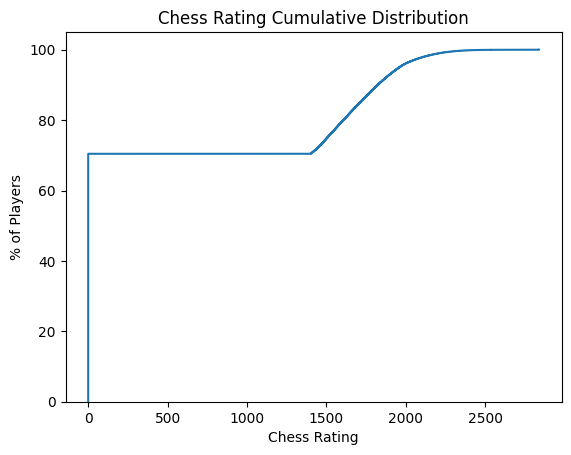

In [12]:
sns.ecdfplot(data=fide, x="SRtng", stat='percent')
plt.xlabel('Chess Rating')
plt.ylabel('% of Players')
plt.title('Chess Rating Cumulative Distribution')
plt.show()